In [1]:
# ! hf auth login --token <your_token>
# ! hf auth login --token 

In [2]:
# ! hf download facebook/sam3 sam3.pt --local-dir /workspace/models/sam3

In [1]:
from ultralytics.models.sam import SAM3SemanticPredictor

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Initialize predictor with configuration
overrides = {
    "conf": 0.25,
    "task": "segment",
    "mode": "predict",
    "model": "/workspace/models/sam3.pt",
    "quantize": 16,  # Use FP16 for faster inference
    "save": False,#True,
}
predictor = SAM3SemanticPredictor(overrides=overrides)

In [3]:
local_image_path = '/workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg'

In [4]:
# Set image once for multiple queries
predictor.set_image(local_image_path)

# Query with multiple text prompts
results = predictor(text=["person", "dog", "bench"])

# # Works with descriptive phrases
# results = predictor(text=["person with red cloth", "person with blue cloth"])

# # Query with a single concept
# results = predictor(text=["a person"])

Ultralytics 8.4.117 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (Quadro RTX 3000, 5927MiB)
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
  Cloning https://github.com/ultralytics/CLIP.git to /tmp/pip-req-build-1cx1a7ig
  Running command git clone --filter=blob:none --quiet https://github.com/ultralytics/CLIP.git /tmp/pip-req-build-1cx1a7ig
  Resolved https://github.com/ultralytics/CLIP.git to commit 488e81a6711eea7346872b46ea928b367da8889d
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1382832 sha256=2340cb001cc0b4cbc857be94f972768b1b4ee6f349f79f57736f064591d1631c
  Store

/root/miniconda3/envs/gsam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg: 644x644 1 dog, 1 bench, 1304.6ms
Speed: 2.0ms preprocess, 1304.6ms inference, 22.1ms postprocess per image at shape (1, 3, 644, 644)


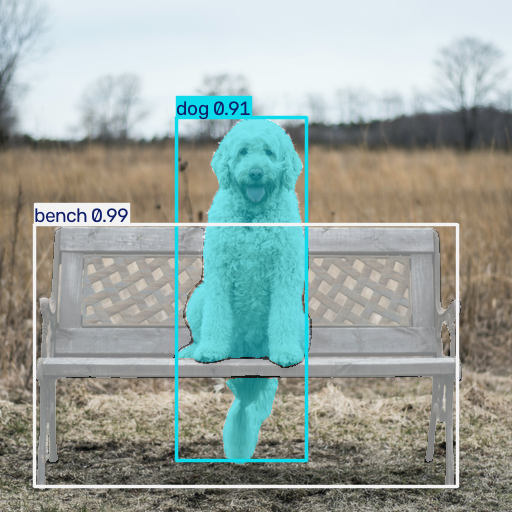

In [5]:
results[0].show()  # Show the first result

In [6]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: ['person', 'dog', 'bench']
 obb: None
 orig_img: array([[[193, 184, 164],
         [202, 191, 173],
         [215, 205, 190],
         ...,
         [241, 232, 222],
         [241, 232, 222],
         [241, 232, 222]],
 
        [[193, 185, 165],
         [204, 193, 175],
         [217, 206, 191],
         ...,
         [241, 232, 222],
         [241, 232, 222],
         [241, 232, 222]],
 
        [[196, 187, 169],
         [206, 194, 178],
         [217, 205, 192],
         ...,
         [241, 232, 222],
         [242, 233, 223],
         [242, 233, 223]],
 
        ...,
 
        [[152, 167, 175],
         [127, 144, 151],
         [138, 157, 164],
         ...,
         [ 98, 108, 112],
         [ 66,  72,  72],
         [113, 115, 115]],
 
        [[151, 166, 170],
         [123, 132, 137

In [8]:
results[0].masks.data.shape

torch.Size([2, 512, 512])

In [9]:
results[0].boxes.cls

tensor([2., 1.], device='cuda:0', dtype=torch.float16)